In [1]:
import os
import tifffile
import math
import numpy as np
from typing import Optional
import scipy.io as sio
import rasterio
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
#from pytorch_msssim import ssim
from torchvision.models import resnet101
from torch.utils.data import Dataset, DataLoader
from torchvision.models.feature_extraction import create_feature_extractor
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler

#from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.manual_seed(42)
print(f"Using device: {device}")

Using device: cuda


In [3]:
patches_folder='samson'
file_prefix='samson_1'

initialization_path = 'Data/Input/ViT_SAMSON_INPUT.pt'

num_endmembers = 3

In [4]:
data = torch.load(initialization_path)

vca_spectra   = data['vca_spectra'].cuda()  # move to GPU if you like
gt_spectra    = data['gt_spectra'].cuda()

print("Loaded data")
print("VCA spectra shape:", vca_spectra.shape)
print("GT spectra shape: ", gt_spectra.shape)

Loaded data
VCA spectra shape: torch.Size([1, 3, 156])
GT spectra shape:  torch.Size([1, 3, 156])


In [5]:
def spectral_angle_loss(recon, target):
    # both [B, F, H, W] → flatten to [B, F, Npix]
    a = recon.view(recon.size(0), recon.size(1), -1)
    b = target.view(target.size(0), target.size(1), -1)
    # cosine similarity
    cs = (a * b).sum(dim=1) / (a.norm(dim=1) * b.norm(dim=1) + 1e-6)
    # angle in radians
    sam = torch.acos(cs.clamp(-1+1e-6, 1-1e-6))
    return sam.mean()

In [6]:
class HSIPatchDataset(Dataset):
    def __init__(self, patches_folder, file_prefix, num_endmembers, vca_tensor, gt_tensor, transform=None):
        """
        Dataset for loading preprocessed and normalized HSI patches with matching VCA/GT spectra.

        Parameters:
            patches_folder (str): Directory where the patch TIFF files are stored.
            file_prefix (str): Filename prefix for the patch files (e.g., "tile761_patch").
            highlight_info (list of tuples): Each tuple is (patch_number, num_endmembers).
            vca_tensor (torch.Tensor): [N, E, bands] per-patch VCA spectra.
            gt_tensor  (torch.Tensor): [N, E, bands] per-patch GT spectra.
            transform (callable, optional): Optional transform to be applied on a patch.
        """
        self.patches_folder = patches_folder
        self.file_prefix = file_prefix
        self.num_endmembers = num_endmembers 
        self.patch_number = 46 
        self.length = 1
        self.vca = vca_tensor.float()
        self.gt = gt_tensor.float()
        self.transform = transform

    def __len__(self):
        return self.length
        
    def __getitem__(self, idx):
        # Unpack the tuple: patch number and number of endmembers
        num_endmembers = self.num_endmembers
        patch_number = self.patch_number
        # Build file path and read TIFF
        filename = f"{self.file_prefix}.img"
        file_path = os.path.join(self.patches_folder, filename)
        with rasterio.open(file_path, driver='ENVI') as src:
            patch = src.read()   # shape: (bands, H, W)
        #patch = patch.transpose(2,0,1)
        # Convert to float32 Tensor
        patch_tensor = torch.from_numpy(patch.astype('float32'))  # [bands, H, W]
        
        # L2‐normalize each pixel's spectrum (across bands)
        flat = patch_tensor.view(patch_tensor.size(0), -1)  # [bands, H*W]
        flat = F.normalize(flat, p=2, dim=0, eps=1e-6)
        patch_tensor = flat.view_as(patch_tensor)          # back to [bands, H, W]
        
        # Optional transform (e.g., augmentations)
        if self.transform:
            patch_tensor = self.transform(patch_tensor)

        # Select and L2‐normalize VCA and GT spectra
        vca_spec = F.normalize(self.vca[idx], p=2, dim=-1, eps=1e-6)  # [E, bands]
        gt_spec  = F.normalize(self.gt[idx],  p=2, dim=-1, eps=1e-6)   # [E, bands]

        return {
            "patch": patch_tensor,              # Tensor: [bands, H, W]
            "vca":   vca_spec,                  # [E, bands]
            "gt":    gt_spec,                   # [E, bands]
            "patch_number": patch_number,       # int
            "num_endmembers": num_endmembers    # int
        }

In [7]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):
        # x: [B, tokens, embed_dim]
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class HSITransformer(nn.Module):
    def __init__(self,
                 bands,
                 embed_dim,
                 num_heads,
                 mlp_dim,
                 num_layers,
                 num_endmembers,
                 patch_size=1,
                 token_mode="full"):
        super().__init__()
        self.patch_size = patch_size
        self.token_mode = token_mode

        num_patches_side = 95 // patch_size
        self.num_patches = num_patches_side ** 2

        self.patch_embed = nn.Conv2d(
            in_channels=bands,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.vca_conv = nn.Conv1d(
            in_channels=bands,
            out_channels=embed_dim,
            kernel_size=1
        )
        self.gt_conv = nn.Conv1d(
            in_channels=bands,
            out_channels=embed_dim,
            kernel_size=1
        )

        if self.token_mode == "full":
            self.num_special_tokens = 3
        elif self.token_mode in ["no_cl", "no_vca"]:
            self.num_special_tokens = 2
        elif self.token_mode == "cls_only":
            self.num_special_tokens = 1
        else:
            raise ValueError(f"Unknown token_mode: {self.token_mode}")

        total_tokens = self.num_special_tokens + self.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, total_tokens, embed_dim))

        self.encoder = nn.Sequential(*[
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim)
            for _ in range(num_layers)
        ])

        self.head = nn.Conv2d(
            embed_dim,
            num_endmembers * patch_size * patch_size,
            kernel_size=1
        )
        self.pixel_shuffle = nn.PixelShuffle(patch_size)

    def forward(self, x, vca_init, gt_init, return_full=False):
        B = x.size(0)

        patches = self.patch_embed(x)
        tokens_local = patches.flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        token_list = [cls_tokens]

        if self.token_mode in ["full", "no_cl"]:
            vca_emb = self.vca_conv(vca_init.permute(0, 2, 1))
            vca_tok = vca_emb.mean(dim=2, keepdim=True).transpose(1, 2)
            token_list.append(vca_tok)

        if self.token_mode in ["full", "no_vca"]:
            gt_emb = self.gt_conv(gt_init.permute(0, 2, 1))
            gt_tok = gt_emb.mean(dim=2, keepdim=True).transpose(1, 2)
            token_list.append(gt_tok)

        token_list.append(tokens_local)
        tokens = torch.cat(token_list, dim=1)

        tokens = tokens + self.pos_embed
        encoded = self.encoder(tokens)

        patch_tokens = encoded[:, self.num_special_tokens:, :]

        Hp = Wp = 95 // self.patch_size
        feat = patch_tokens.transpose(1, 2).view(
            B, self.patch_embed.out_channels, Hp, Wp
        )

        ab_logits = self.head(feat)            # [B, E*P*P, Hp, Wp]
        ab_map = self.pixel_shuffle(ab_logits) # [B, E, H, W]
        ab_map = F.softmax(ab_map, dim=1)

        return ab_map

    def _reconstruct_with_fold(self, ab_patch):
            B, C, P_h, P_w = ab_patch.shape
            num_patches    = P_h * P_w
            patch_area     = self.patch_size * self.patch_size
    
            # Flatten to (B, C, L)
            patches = ab_patch.view(B, C, num_patches)
    
            # Expand each patch element into patch_area
            patches = patches.unsqueeze(-1).expand(-1, -1, -1, patch_area)
            patches = patches.reshape(B, C * patch_area, num_patches)
    
            # Fold back to (B, C, 256, 256)
            full_map = self.fold(patches)
            return full_map

In [11]:
# 0) Early stopping params
patience           = 100              # quante epoche di plateau prima di fermarsi
best_loss          = float('inf')     # inizialmente infinito
epochs_without_improvement = 0

# 1) Hyperparameters
lr          = 1e-3
num_epochs  = 1000
batch_size  = 1

# 2) Model, optimizer, loss
# model       = HSITransformer(
#     bands=156, embed_dim=64,
#     num_heads=2, mlp_dim=128, num_layers=4,
#     num_endmembers=num_endmembers,
#     patch_size=1
# )
TOKEN_MODE = "full"   # choose from: "full", "no_cl", "no_vca", "cls_only"
PATCH_SIZE = 5        # for Samson, use 1 or 5

model = HSITransformer(
    bands=156,               # Samson has 95 bands after band removal
    embed_dim=64,
    num_heads=2,
    mlp_dim=128,
    num_layers=4,
    num_endmembers=num_endmembers,   # should be 3 for Samson
    patch_size=PATCH_SIZE,
    token_mode=TOKEN_MODE
)

pos_init = model.pos_embed.detach().cpu().clone().numpy()[0] 
# 2) If you have more than 1 GPU, wrap in DataParallel
if torch.cuda.device_count() > 1:
    print(f"Detected {torch.cuda.device_count()} GPUs. Using DataParallel.")
    model = nn.DataParallel(model, device_ids=[0,1,2])

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,} "
      f"({total_params/1e6:.3f} M)")
print(f"Trainable parameters: {trainable_params:,} "
      f"({trainable_params/1e6:.3f} M)")

optimizer   = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
               mode='min', factor=0.1, patience=50, min_lr=1e-5)
criterion   = nn.MSELoss()


# right after you load/model-init your vca/gt
vca_spectra_cpu = vca_spectra.detach().cpu()
gt_spectra_cpu = gt_spectra.detach().cpu()

# 3) DataLoader (reuse your HSIPatchDataset)
dataset     = HSIPatchDataset(
    patches_folder=patches_folder,
    file_prefix=file_prefix,
    num_endmembers=3,
    vca_tensor=vca_spectra_cpu,    # [N, E, bands]
    gt_tensor=gt_spectra_cpu       # [N, E, bands]
)
dataloader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

Total parameters: 431,883 (0.432 M)
Trainable parameters: 431,883 (0.432 M)


In [12]:
# Reset CUDA peak memory stats before training
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(device)
    
# 4) Training loop
loss_history = []

# start overall timer
train_start_time = time.time()

for epoch in range(1, num_epochs+1):
    epoch_start_time = time.time()
    
    model.train()
    running_loss = 0.0

    for batch in dataloader:
        x      = batch['patch'].to(device, non_blocking=True)   # [B, bands, H, W]
        vca    = batch['vca'].to(device, non_blocking=True)     # [B, E, bands]
        gt     = batch['gt'].to(device, non_blocking=True)      # [B, E, bands]

        optimizer.zero_grad()

        # forward pass → abundance maps [B, E, H, W]
        abundances = model(x, vca, gt)

        # reconstruct the patch: R[b,f,i,j] = sum_e abundances[b,e,i,j] * vca[b,e,f]
        # Using einsum for clarity:
        reconstruction = torch.einsum('behw,bef->bfhw', abundances, vca)
        
        # # 1) Upsample a 256×256
        # reconstruction= F.interpolate(
        #     reconstruction,
        #     size=(x.shape[2], x.shape[3]),    # (256,256)
        #     mode='bilinear',
        #     align_corners=False
        # )
        
        # compute MSE loss between original and reconstruction
        # in training:
        loss_mse = criterion(reconstruction, x)
        loss_sam = spectral_angle_loss(reconstruction, x)
        loss = 0.1*loss_mse + 0.1 * loss_sam
        #loss = criterion(reconstruction, x)

        loss.backward()
        
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(dataset)
    loss_history.append(epoch_loss)

    epoch_time = time.time() - epoch_start_time
    print(f"Epoch {epoch}/{num_epochs} — Loss: {epoch_loss:.6f}")
    scheduler.step(epoch_loss)

    # --- Early stopping check ---
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        epochs_without_improvement = 0
        # (opzionale) salva il modello migliore
        #torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_without_improvement += 1
        print(f"  ↳ nessun miglioramento per {epochs_without_improvement}/{patience} epoche")

    if epochs_without_improvement >= patience:
        print(f"Early stopping dopo {epoch} epoche (pazienza esaurita).")
        break

# end overall timer
train_end_time = time.time()
total_train_time = train_end_time - train_start_time
print("Training complete.")
print(f"Total training time: {total_train_time:.2f} seconds ")
# Report peak GPU memory usage
if torch.cuda.is_available():
    peak_mem_bytes = torch.cuda.max_memory_allocated(device)
    peak_mem_gb = peak_mem_bytes / (1024 ** 3)
    print(f"Peak GPU memory during training: {peak_mem_gb:.2f} GB")

Epoch 1/1000 — Loss: 0.040501
Epoch 2/1000 — Loss: 0.037871
Epoch 3/1000 — Loss: 0.035292
Epoch 4/1000 — Loss: 0.033636
Epoch 5/1000 — Loss: 0.032864
Epoch 6/1000 — Loss: 0.032536
Epoch 7/1000 — Loss: 0.032170
Epoch 8/1000 — Loss: 0.031633
Epoch 9/1000 — Loss: 0.030996
Epoch 10/1000 — Loss: 0.030292
Epoch 11/1000 — Loss: 0.029341
Epoch 12/1000 — Loss: 0.028007
Epoch 13/1000 — Loss: 0.026245
Epoch 14/1000 — Loss: 0.023994
Epoch 15/1000 — Loss: 0.021305
Epoch 16/1000 — Loss: 0.018796
Epoch 17/1000 — Loss: 0.017145
Epoch 18/1000 — Loss: 0.017495
  ↳ nessun miglioramento per 1/100 epoche
Epoch 19/1000 — Loss: 0.016398
Epoch 20/1000 — Loss: 0.015947
Epoch 21/1000 — Loss: 0.015000
Epoch 22/1000 — Loss: 0.015091
  ↳ nessun miglioramento per 1/100 epoche
Epoch 23/1000 — Loss: 0.013700
Epoch 24/1000 — Loss: 0.013517
Epoch 25/1000 — Loss: 0.012888
Epoch 26/1000 — Loss: 0.012487
Epoch 27/1000 — Loss: 0.012219
Epoch 28/1000 — Loss: 0.011487
Epoch 29/1000 — Loss: 0.011210
Epoch 30/1000 — Loss: 0.01

In [13]:
# %%
import time
import numpy as np
import torch

model.eval()

# take one representative batch
batch = next(iter(dataloader))
x   = batch["patch"].to(device, non_blocking=True)
vca = batch["vca"].to(device, non_blocking=True)
gt  = batch["gt"].to(device, non_blocking=True)

# optional: if using DataParallel, underlying model is still fine through model(...)
# no change needed

# -----------------------------
# 1) Warm-up
# -----------------------------
with torch.no_grad():
    for _ in range(20):
        _ = model(x, vca, gt)

torch.cuda.synchronize()

# -----------------------------
# 2) Measure inference latency
# -----------------------------
n_runs = 100
latencies = []

torch.cuda.reset_peak_memory_stats(device)

with torch.no_grad():
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = model(x, vca, gt)
        torch.cuda.synchronize()
        end = time.perf_counter()
        latencies.append(end - start)

avg_latency_s = float(np.mean(latencies))
std_latency_s = float(np.std(latencies))
fps = 1.0 / avg_latency_s
peak_inference_mem_gb = torch.cuda.max_memory_allocated(device) / (1024**3)

print(f"Average inference latency: {avg_latency_s*1000:.3f} ms/image")
print(f"Latency std: {std_latency_s*1000:.3f} ms")
print(f"FPS: {fps:.3f}")
print(f"Peak inference memory: {peak_inference_mem_gb:.3f} GB")

Average inference latency: 2.415 ms/image
Latency std: 0.010 ms
FPS: 414.043
Peak inference memory: 0.053 GB


In [14]:
def visualize_abundances_with_patch(abundances, patches, patch_ids=None, band=12, figsize_per=3):
    """
    Visualizza un batch di abundance maps disposte in due righe:
      - riga 0: il patch nella banda specificata (nel primo subplot)
      - riga 1: le E abundance maps (una per endmember)

    Parameters:
        abundances (torch.Tensor): [B, E, H, W] output del modello.
        patches    (torch.Tensor): [B, bands, H, W] input originale.
        patch_ids  (list[int], optional): identificativi delle patch.
        band       (int): indice della banda da mostrare, default 12.
        figsize_per(float): dimensione di ciascun subplot in pollici.
    """
    import matplotlib.pyplot as plt

    abund_np = abundances.detach().cpu().numpy()
    patch_np  = patches.detach().cpu().numpy()
    B, E, H, W = abund_np.shape

    for i in range(B):
        fig, axes = plt.subplots(2, E, 
                                 figsize=(figsize_per * E, figsize_per * 2),
                                 squeeze=False)
        # --- prima riga: patch (band 'band') in axes[0,0], gli altri a vuoto
        ax0 = axes[0, 0]
        im0 = ax0.imshow(patch_np[i, band], cmap='gray')
        title = f'Patch {patch_ids[i]}' if patch_ids else f'Sample {i}'
        ax0.set_title(f'{title}\nBand {band}')
        ax0.axis('off')
        fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

        # nascondi eventuali subplot vuoti in prima riga
        for j in range(1, E):
            axes[0, j].axis('off')

        # --- seconda riga: le E abundance maps
        for e in range(E):
            ax = axes[1, e]
            im = ax.imshow(abund_np[i, e], cmap='jet', vmin=0, vmax=1)
            ax.set_title(f'EM {e}')
            ax.axis('off')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

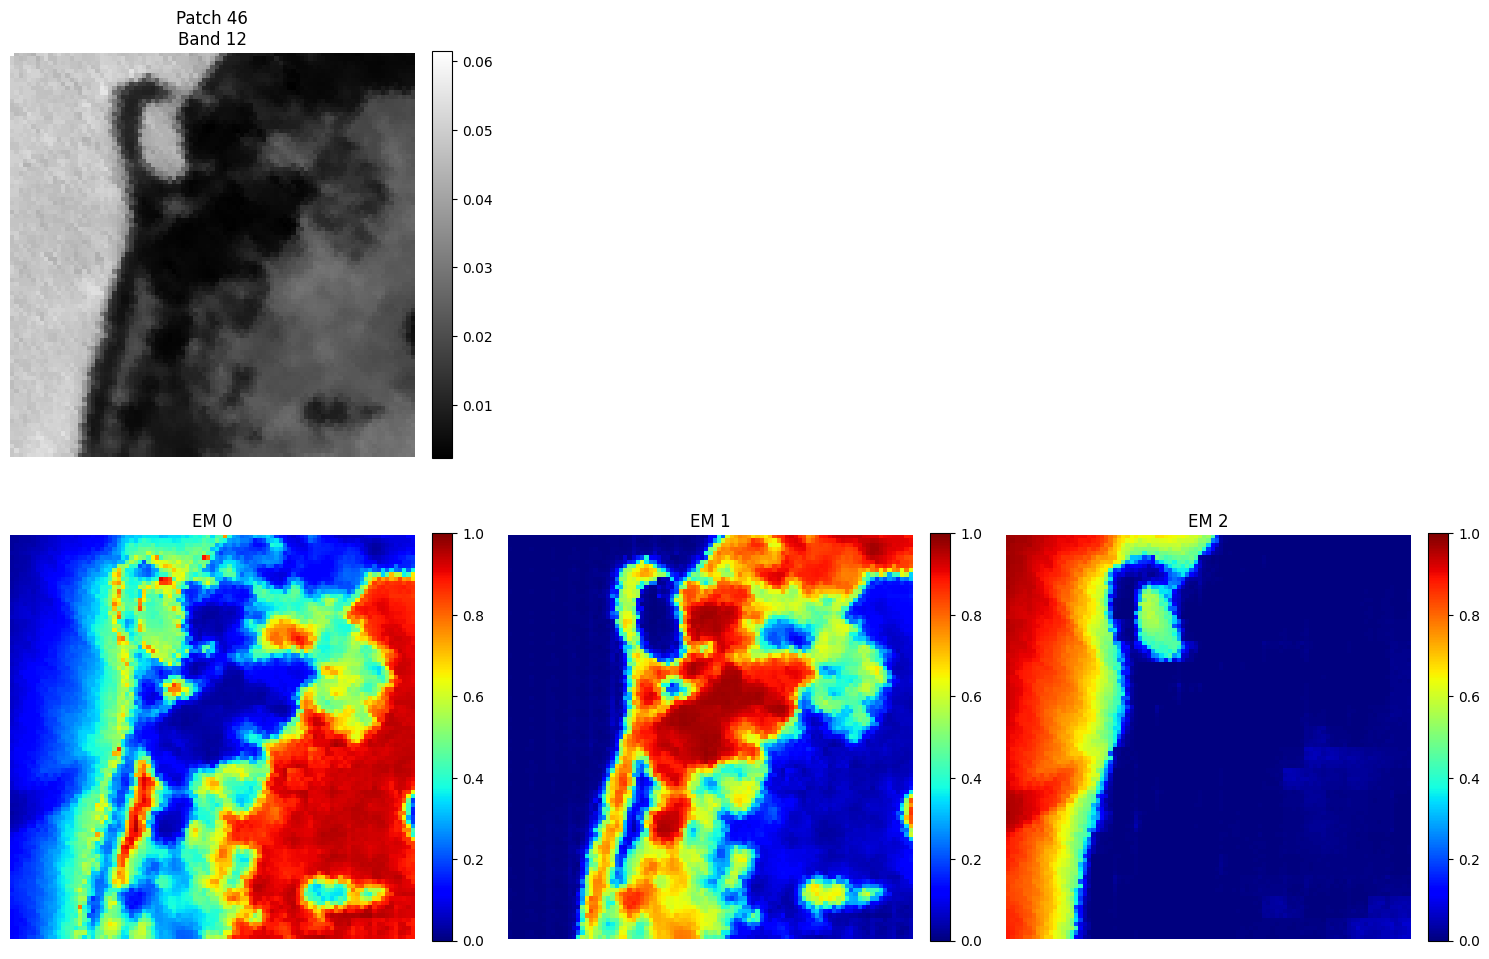

In [16]:
# prendi un batch
batch = next(iter(dataloader))
x          = batch['patch']        # [B, bands, H, W]
abundances = model(x.cuda(), batch['vca'].cuda(), batch['gt'].cuda(),return_full=True)
patch_ids  = batch['patch_number'] # lista di interi

visualize_abundances_with_patch(
    abundances,
    x,
    patch_ids=patch_ids,
    band=12,
    figsize_per=5
)

Best GT orientation: rot270_fliplr
Channel matching (pred -> GT): [(0, 0), (1, 1), (2, 2)]

Per-endmember RMSE:
E0: 0.090865
E1: 0.063415
E2: 0.058093
Overall RMSE: 0.072233


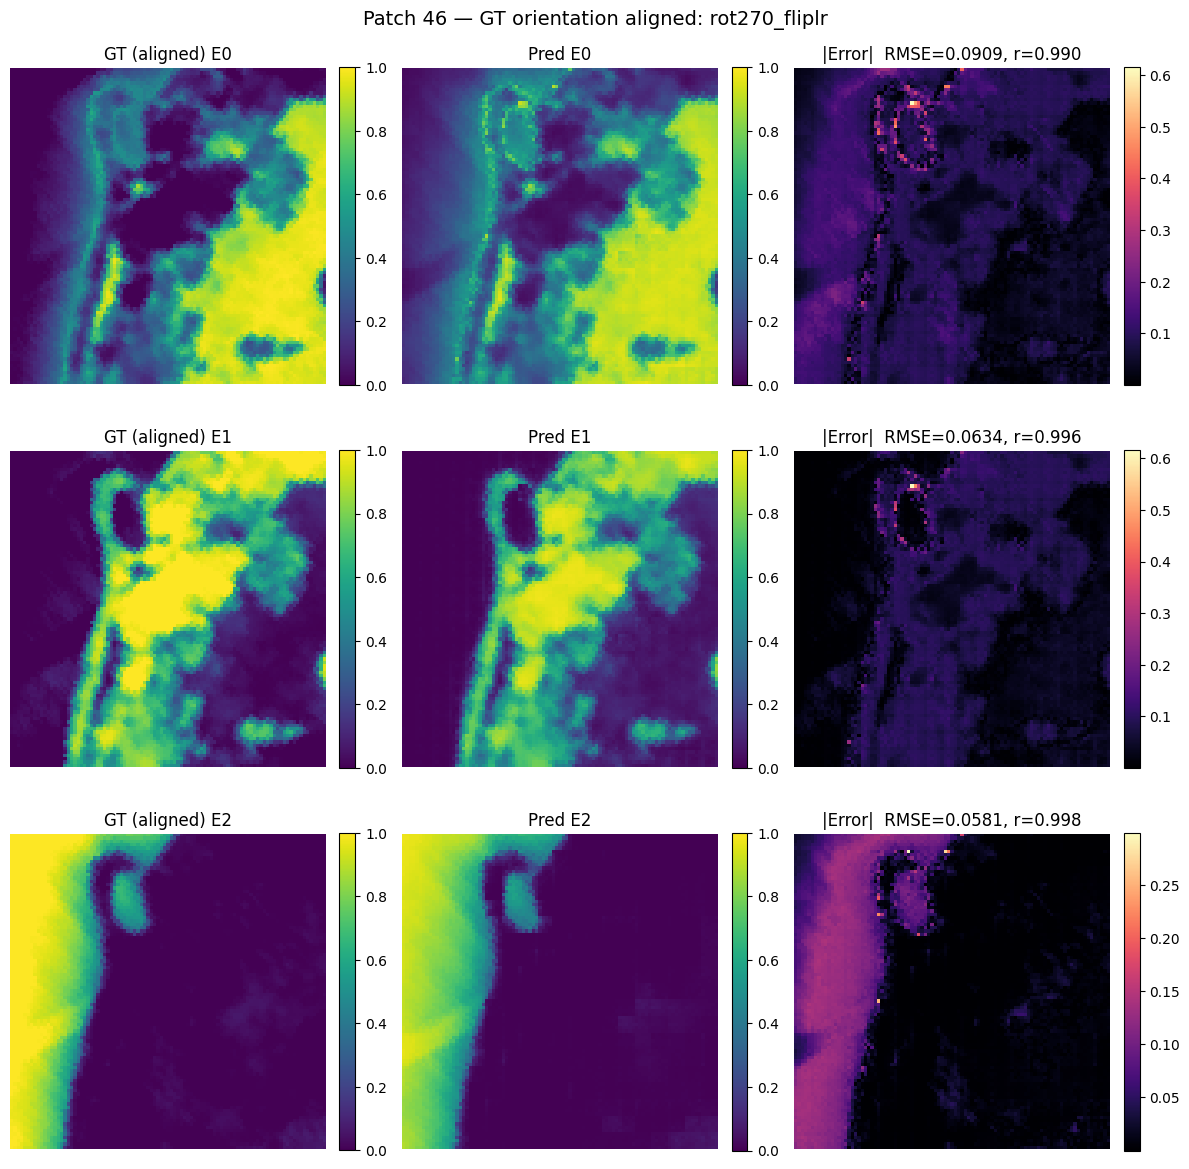

In [19]:
# --- RMSE + side-by-side viz with automatic GT orientation alignment ---

import os, re
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import linear_sum_assignment

# pred abundances already computed in previous cell
pred = abundances.detach().float()  # [B,E,H,W]
B, E, H, W = pred.shape
device = pred.device

# ---------- load GT as before (coerce to [E,H,W]) ----------
candidate_paths = [
    "samson/end3.mat"
]
candidate_paths = [p for p in candidate_paths if os.path.exists(p)]
if not candidate_paths:
    raise FileNotFoundError("No GT .mat files. Update candidate_paths.")

def coerce_to_ehw(arr, E, H, W):
    a = np.array(arr); a = np.squeeze(a)
    if a.ndim == 4 and 1 in a.shape: a = np.squeeze(a)
    if a.ndim == 3:
        if a.shape == (E,H,W): return a
        if a.shape == (H,W,E): return np.transpose(a, (2,0,1))
        if a.shape[0]==E and a.shape[1]*a.shape[2]==H*W: return a.reshape(E,H,W)
        if a.shape[2]==E and a.shape[0]*a.shape[1]==H*W: return np.transpose(a,(2,0,1)).reshape(E,H,W)
    if a.ndim == 2:
        if a.shape == (E, H*W): return a.reshape(E,H,W)
        if a.shape == (H*W, E): return a.T.reshape(E,H,W)
    return None

def user_vars(md): return [k for k in md if not k.startswith("__")]

chosen = None; chosen_src = None; debug = []
for p in candidate_paths:
    md = loadmat(p); keys = user_vars(md)
    for k in keys:
        ehw = coerce_to_ehw(md[k], E, H, W)
        if ehw is not None:
            chosen = ehw.astype(np.float32); chosen_src = (p, k); break
    if chosen is not None: break
    debug.append((p, {k: np.array(md[k]).shape for k in keys}))

if chosen is None:
    # fallback: stack 2D [H,W] maps across files
    two_d = []
    def sort_key(x):
        m = re.search(r'(\d+)', os.path.basename(x))
        return int(m.group(1)) if m else x
    for p in sorted(candidate_paths, key=sort_key):
        md = loadmat(p)
        for k in user_vars(md):
            a = np.squeeze(np.array(md[k]))
            if a.ndim == 2 and a.shape == (H, W):
                two_d.append(a.astype(np.float32)); break
    if len(two_d) < E:
        print("Could not build [E,H,W]. Variables seen:")
        for p, shapes in debug:
            print(f"\nFile: {p}")
            for k, s in shapes.items(): print(f"  - {k}: {s}")
        raise SystemExit
    chosen = np.stack(two_d[:E], axis=0)  # [E,H,W]
    chosen_src = ("stacked-2D", [p for p in sorted(candidate_paths, key=sort_key)[:E]])

# ---------- orientation search over D4 (8 transforms) ----------
def dihedral8(ehw):
    outs = []
    for k in range(4):
        r = np.rot90(ehw, k, axes=(1,2))        # rotate on spatial axes
        outs.append((f"rot{k*90}", r))
        outs.append((f"rot{k*90}_fliplr", np.flip(r, axis=2)))
    return outs  # 8 candidates

def corr_matrix(pred_np, gt_ehw):
    # mean correlation across batch
    E = pred_np.shape[1]
    C = np.zeros((E, E), dtype=np.float64)
    for i in range(E):
        P = pred_np[:, i, :, :].reshape(B, -1)  # [B, H*W]
        Pm = P - P.mean(axis=1, keepdims=True)
        Ps = Pm.std(axis=1, keepdims=True) + 1e-12
        for j in range(E):
            G = np.tile(gt_ehw[j].ravel(), (B, 1))  # [B, H*W]
            Gm = G - G.mean(axis=1, keepdims=True)
            Gs = Gm.std(axis=1, keepdims=True) + 1e-12
            r = (Pm * Gm).mean(axis=1) / (Ps.squeeze() * Gs.squeeze())
            C[i, j] = np.mean(r)
    return C

pred_np = pred.detach().cpu().numpy()
best = None
for name, gt_or in dihedral8(chosen):
    C = corr_matrix(pred_np, gt_or)
    row_ind, col_ind = linear_sum_assignment(-C)   # maximize corr
    score = C[row_ind, col_ind].sum()
    if (best is None) or (score > best["score"]):
        best = {"name": name, "gt": gt_or, "C": C, "perm": col_ind, "score": score}

gt_oriented   = best["gt"]                 # [E,H,W] after best orientation
perm          = best["perm"]               # pred idx -> GT idx
gt_aligned_eh = gt_oriented[perm]          # reorder channels to match pred order

print(f"Best GT orientation: {best['name']}")
print(f"Channel matching (pred -> GT): {list(zip(range(E), perm.tolist()))}")

# ---------- metrics ----------
gt_t = torch.from_numpy(gt_aligned_eh).to(device)    # [E,H,W]
gt_t = gt_t.unsqueeze(0).expand(B, -1, -1, -1)       # [B,E,H,W]

mse_hw = F.mse_loss(pred, gt_t, reduction="none").mean(dim=(2, 3))   # [B,E]
rmse_per_em  = torch.sqrt(mse_hw).mean(dim=0)                        # [E]
overall_rmse = torch.sqrt(F.mse_loss(pred, gt_t))

print("\nPer-endmember RMSE:")
for e in range(E):
    print(f"E{e}: {rmse_per_em[e].item():.6f}")
print(f"Overall RMSE: {overall_rmse.item():.6f}")

# ---------- side-by-side plot for one patch ----------
b_idx = 0  # change to inspect another patch
pred_maps = pred[b_idx].detach().cpu().numpy()      # [E,H,W]
gt_maps   = gt_aligned_eh                           # [E,H,W]

# correlations for the chosen orientation + permutation (per endmember, this patch)
r_per_em = []
for i in range(E):
    p = pred_maps[i].ravel(); g = gt_maps[i].ravel()
    ps, gs = p.std(), g.std()
    r = 0.0 if (ps == 0 or gs == 0) else np.corrcoef(p, g)[0, 1]
    r_per_em.append(r)

fig, axes = plt.subplots(E, 3, figsize=(12, 4*E))
if E == 1: axes = np.expand_dims(axes, 0)

for i in range(E):
    vmin = min(gt_maps[i].min(), pred_maps[i].min())
    vmax = max(gt_maps[i].max(), pred_maps[i].max())

    im0 = axes[i, 0].imshow(gt_maps[i], cmap="viridis", vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"GT (aligned) E{i}")
    axes[i, 0].axis("off"); fig.colorbar(im0, ax=axes[i,0], fraction=0.046, pad=0.04)

    im1 = axes[i, 1].imshow(pred_maps[i], cmap="viridis", vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"Pred E{i}")
    axes[i, 1].axis("off"); fig.colorbar(im1, ax=axes[i,1], fraction=0.046, pad=0.04)

    diff = np.abs(pred_maps[i] - gt_maps[i])
    im2 = axes[i, 2].imshow(diff, cmap="magma")
    axes[i, 2].set_title(f"|Error|  RMSE={np.sqrt(np.mean(diff**2)):.4f}, r={r_per_em[i]:.3f}")
    axes[i, 2].axis("off"); fig.colorbar(im2, ax=axes[i,2], fraction=0.046, pad=0.04)

pid_str = f"{int(patch_ids[b_idx])}" if "patch_ids" in locals() else f"{b_idx}"
fig.suptitle(f"Patch {pid_str} — GT orientation aligned: {best['name']}", fontsize=14)
plt.tight_layout()
plt.show()


In [20]:
ab_np = abundances[0].detach().cpu().numpy()   # → (E, H, W)
ab_np.shape
np.save('ViT_samson_abundances_b08_P5.npy', ab_np)

/tmp/ipykernel_3267344/2720605449.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
/tmp/ipykernel_3267344/2720605449.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
/tmp/ipykernel_3267344/2720605449.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)


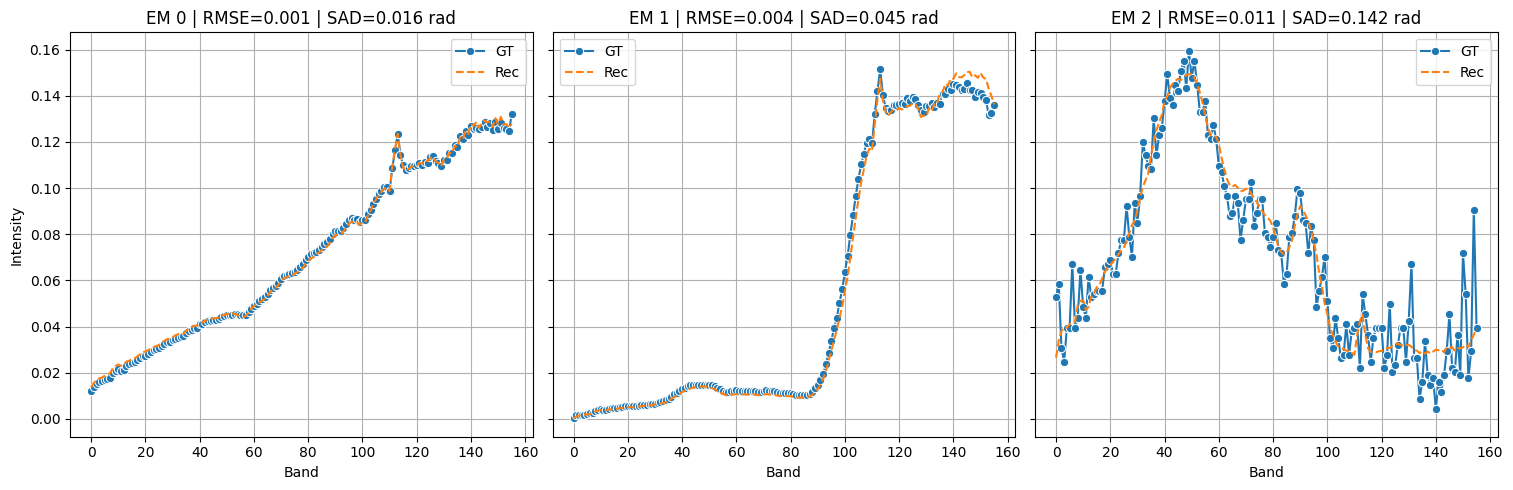

In [22]:
from sklearn.metrics import mean_squared_error

def spectral_angle(a, b):
    """SAD in radians between two 1D NumPy arrays."""
    cos = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
    cos = np.clip(cos, -1, 1)
    return np.arccos(cos)

def weighted_median(data, weights):
    """
    Compute the weighted median of 1D `data` with positive `weights`.
    """
    # sort data and weights by data value
    idx = np.argsort(data)
    d = data[idx]
    w = weights[idx]
    cum = np.cumsum(w)
    cutoff = w.sum() / 2.0
    return d[np.searchsorted(cum, cutoff)]

# 1) Fetch one patch, its abundances, and the GT spectra
batch  = next(iter(dataloader))
x_t    = batch['patch'][0].cpu()       # [bands, H, W]
abund_t= (model(batch['patch'].cuda(),
                batch['vca'].cuda(),
                batch['gt'].cuda(),return_full=True)
           .detach()
           .cpu()[0])                   # [E, h', w']
spec_gt= batch['gt'][0].cpu()          # [E, bands]

# 2) Convert to NumPy and check shapes
fm1 = abundances.detach().cpu()[0]
x_np     = x_t.numpy()                 # [bands, H, W]
abund_np = fm1.numpy()             # [E, h', w']
gt_np    = spec_gt.numpy()             # [E, bands]

bands, H, W = x_np.shape
E,  h2, w2  = abund_np.shape

lower_thresh = 0.9
upper_thresh =1
E =3
rec_specs = []
for e in range(E):
    a = fm1[e]   # [h', w'] abundance map for endmember e
    # keep only pixels with lower_thresh < a < upper_thresh
    mask = (a > lower_thresh) & (a < upper_thresh)  

    if mask.sum() == 0:
        rec_specs.append(torch.zeros(bands, device=x_t.device))
        continue

    selected = x_t[:, mask]           # [bands, N_pixels]
    med = selected.median(dim=1).values  # [bands]
    rec_specs.append(med)

rec_specs = torch.stack(rec_specs)      # [E, bands]

# 5) Plot GT vs. Rec with RMSE & SAD
cols      = 4
rows      = int(np.ceil(E / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 5), sharex=True, sharey=True)
axes      = axes.flatten()
x_axis    = np.arange(bands)

for i in range(E):
    ax   = axes[i]
    sns.lineplot(x=x_axis, y=gt_np[i],  ax=ax, label='GT', marker='o')
    sns.lineplot(x=x_axis, y=rec_specs[i], ax=ax, label='Rec', linestyle='--')
    rmse = np.sqrt(mean_squared_error(gt_np[i], rec_specs[i]))
    sad  = spectral_angle(gt_np[i], rec_specs[i])
    ax.set_title(f'EM {i} | RMSE={rmse:.3f} | SAD={sad:.3f} rad')
    ax.set_xlabel('Band')
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.grid(True)

# remove unused axes
for j in range(E, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


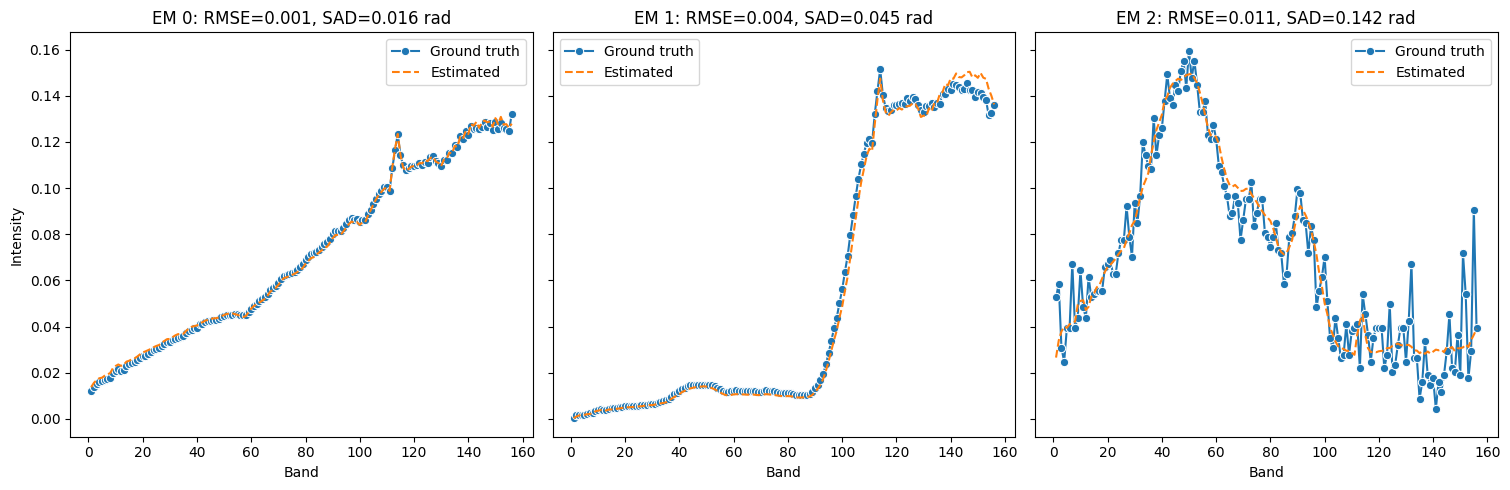

In [23]:
def spectral_angle(a, b):
    """SAD in radians between two 1D NumPy arrays."""
    cos_val = np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-12)
    cos_val = np.clip(cos_val, -1, 1)
    return np.arccos(cos_val)

# 1) Fetch one batch
batch = next(iter(dataloader))
x_t = batch['patch'][0].cpu()    # [bands, H, W]
abund_tensor = (model(batch['patch'].cuda(),
                       batch['vca'].cuda(),
                       batch['gt'].cuda(),return_full=True)
                .detach()
                .cpu()[0])      # [E, h', w']
spec_gt = batch['gt'][0].cpu()    # [E, bands]

# 2) Convert to NumPy
x_np = x_t.numpy()                       # [bands, H, W]
abund_np = abund_tensor.numpy()          # [E, h', w']
gt_np = spec_gt.numpy()                  # [E, bands]

bands, H, W = x_np.shape
E = gt_np.shape[0]

# 3) Reconstruct spectra via median on high-abundance pixels
lower_thresh = 0.90
upper_thresh = 1.0
rec_specs = []

for e in range(E):
    a_map = abund_tensor[e]  # tensor [h', w']
    mask = (a_map > lower_thresh) & (a_map < upper_thresh)
    if mask.sum() == 0:
        rec_specs.append(np.zeros(bands))
        continue
    # select pixel spectra: shape [bands, N_pixels]
    selected = x_t[:, mask.numpy()]
    # median along pixels
    med = selected.median(dim=1).values.numpy()
    rec_specs.append(med)

rec_specs = np.stack(rec_specs, axis=0)  # [E, bands]

# 4) Undo L2-normalization by scaling with ground-truth norms
# compute GT endmember L2 norms

norms_gt = np.linalg.norm(gt_np, axis=1)  # (E,)
rec_specs_unnorm = rec_specs * norms_gt[:, None]  # [E, bands]

# 5) Plot GT vs. Reconstructed (unnormalized) with metrics
cols = 4
rows = int(np.ceil(E / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 5), sharex=True, sharey=True)
axes = axes.flatten()
x_axis = np.arange(1, bands + 1)

for i in range(E):
    ax = axes[i]
    sns.lineplot(x=x_axis, y=gt_np[i], ax=ax, label='Ground truth', marker='o')
    sns.lineplot(x=x_axis, y=rec_specs_unnorm[i], ax=ax, label='Estimated', linestyle='--')
    rmse = np.sqrt(mean_squared_error(gt_np[i], rec_specs_unnorm[i]))
    sad = spectral_angle(gt_np[i], rec_specs_unnorm[i])
    ax.set_title(f'EM {i}: RMSE={rmse:.3f}, SAD={sad:.3f} rad')
    ax.set_xlabel('Band')
    ax.set_ylabel('Intensity')
    ax.legend()
    ax.grid(False)

# remove unused axes
for j in range(E, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
np.save('ViT_Endmembers_SAMSON_b08_P5.npy', rec_specs_unnorm)